# Pricing Factor Analysis

To know whether this company follows a dynamic pricing model, we can look at the graphs of when comparing `Historical_Cost_of_Ride` with all `NUMERIC_COLUMNS` and `CATEGORICAL_COLUMNS`, and seeing the correlation between each one. A graph without much incline may indicate little correlation between said two variables, but may also be interfered by noise or bad/inaccurate data.

## 1. Imports

First, we import `pandas`, `matplotlib` and `numpy` to be able to handle dataframes, do calculations with the data extracted from said dataframe, and then finally graphs it, which it then can save using `save_chart`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import save_chart

## 2. Choose the target and the factors

In this block we are setting the target variable to `Historical_Cost_of_Ride` as to have a set variable to compare the independent variables within `NUMERIC_COLUMNS` and `CATEGORICAL_COLUMNS`. The `NUMERIC_COLUMNS` make quite nice graphs through setting X amount of points, then doing linear regression across all of them to get a linear line, while using the independent variables gained in `CATEGORICAL_COLUMNS`, gives a box plot where the median is shown along with where 50% of the values lie within, with whiskers showing the range.

In [ ]:
TARGET = "Historical_Cost_of_Ride"
NUMERIC_COLUMNS = [
    "Number_of_Riders",
    "Number_of_Drivers",
    "Number_of_Past_Rides",
    "Average_Ratings",
    "Expected_Ride_Duration",
]
CATEGORICAL_COLUMNS = [
    "Location_Category",
    "Customer_Loyalty_Status",
    "Time_of_Booking",
    "Vehicle_Type",
]

## 3. Numeric factors vs price

The function `plot_numeric_scatter` takes in `NUMERIC_COLUMNS`, processing them one at a time, outputting `r`, the correlation coefficient between the target variable and each of the independent variables from the numeric columns. 

First, we take in the data table, choose which `column` we are looking at, and whether or not we are saving it.

As the goal with this function is to make a graph which represents `r` while using a simple linear regression, we create a empty graph using `plt.figure`, and then plot in the points one by one, using `plt.scatter` with `alpha=0.4` as to make the dots seethrough so overlapping dots can be seen/spotted.

Next, to generate the line itself, we first calculate the `slope` and the `intercept` using `np.polyfit` so we know where to put the graph on the y-axis, and with what steepness, which we then put  

Lastly, we calculate the correlation coefficient `r` using `dataframe[column].corr(dataframe[TARGET])` which will always be between -1 and 1, where the closer the number is to either -1 or 1, the greater the correlation. In the end, we quickly set the label of the axis of the current graph being generated.


After running the function, we can see that most graphs have a relatively low correlation coefficient with `4/5` graphs having little to no correlation, while the column `Expected_Ride_Duration` from `NUMERIC_COLUMNS` has a very high correlation coefficient of `r=0.93`. This suggests a strong relationship between `Historical_Cost_of_Ride` and `Expected_Ride_Duration`, indicating currently that `Expected_Ride_Duration` is the strongest driver of price so far.


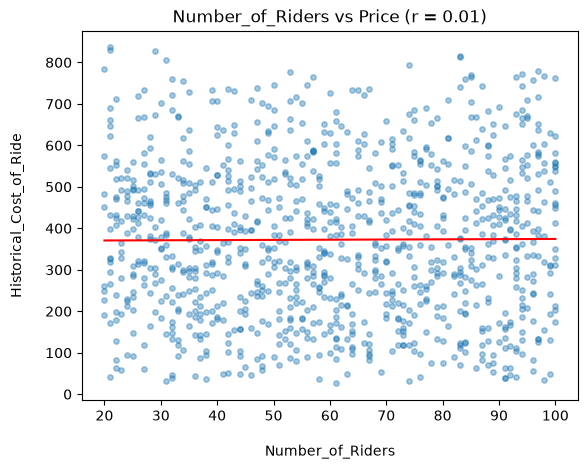

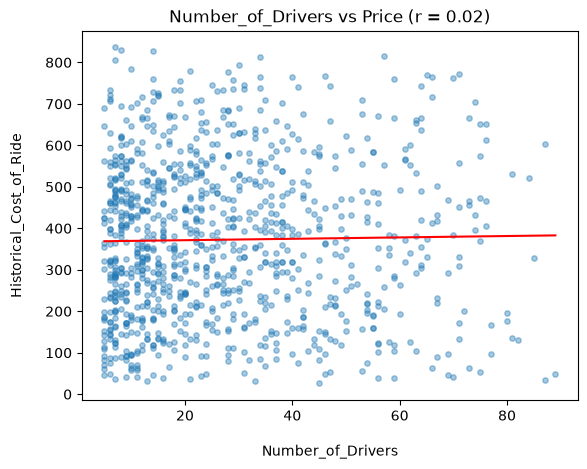

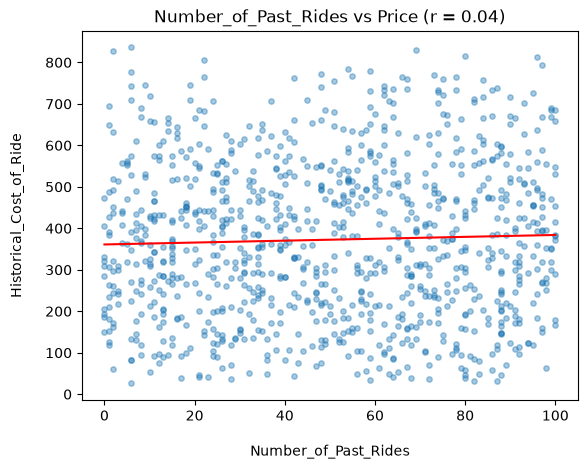

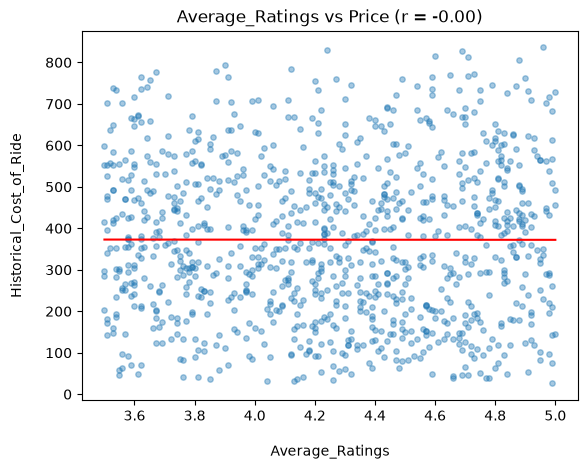

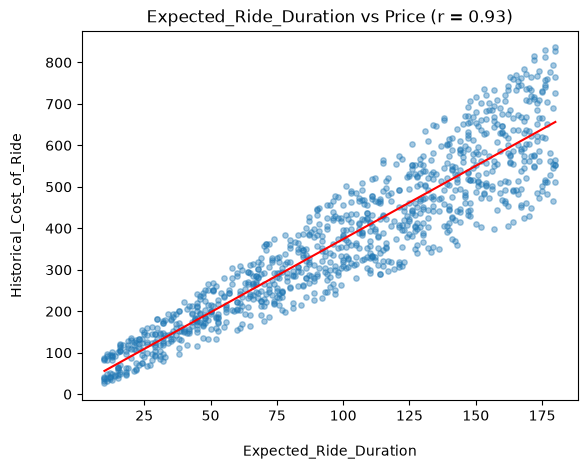

In [ ]:
def plot_numeric_scatter(dataframe, column, save=False):
    fig = plt.figure(figsize=(7, 4))

    plt.scatter(dataframe[column], dataframe[TARGET], alpha=0.4, s=15)

    slope, intercept = np.polyfit(dataframe[column], dataframe[TARGET], 1)
    x_line = np.array([dataframe[column].min(), dataframe[column].max()])
    plt.plot(x_line, slope * x_line + intercept, color="red")

    r = dataframe[column].corr(dataframe[TARGET])
    plt.xlabel(column, labelpad=15)
    plt.ylabel(TARGET, labelpad=15)
    plt.title(f"{column} vs Price (r = {r:.2f})")
    plt.tight_layout()

    if save:
        save_chart.save_chart(fig, f"{column.lower()}_vs_price.png")
    else:
        plt.show()

## 4. Correlation heatmap

The function `plot_correlation_heatmap` takes in all of `NUMERIC_COLUMNS` together with `TARGET`, calculating the correlation coefficient `r` between every possible pair of these columns at once, rather than one at a time.

First, we take in the data table, choose which `column` we are looking at, and whether or not we are saving it.

As the goal with this function is to visualize how every numeric column relates to every other numeric column, we create an empty graph using `plt.figure`, then calculate the full table of correlation values using `dataframe[NUMERIC_COLUMNS + [TARGET]].corr()`, storing it as `corr`.

Next, to turn this table of numbers into something visual, we use `plt.imshow` to draw each value as a colored square, using `cmap="coolwarm"` so that negative correlations appear blue and positive correlations appear red, with `vmin=-1, vmax=1` fixing the color scale so it's consistent across the whole chart, as `r` may not go outside [-1,1]

We then label both axes with the actual column names using `plt.xticks` and `plt.yticks`, and loop through every square in the grid using `plt.text` to write the exact correlation number directly onto its corresponding square, as to make it easier to interpret for the human eye.

After running the function, we can see that `Expected_Ride_Duration` again stands out with the strongest correlation to `Historical_Cost_of_Ride`, matching what we saw in the scatter plots, while most other numeric columns show only weak relationships with price and with each other.

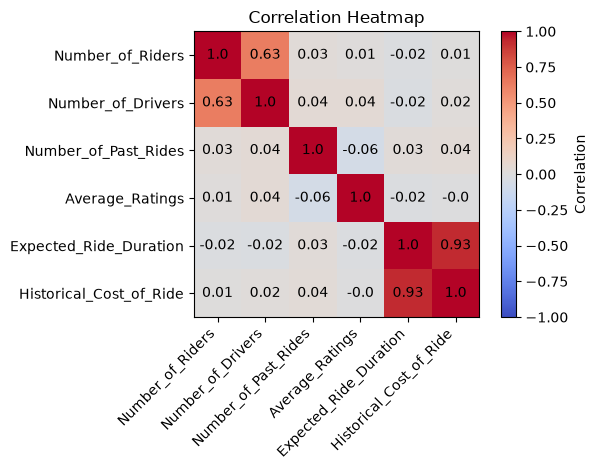

In [ ]:
def plot_correlation_heatmap(dataframe, save=False):
    fig = plt.figure(figsize=(7, 4))

    corr = dataframe[NUMERIC_COLUMNS + [TARGET]].corr()

    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Heatmap")

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

    plt.tight_layout()

    if save:
        save_chart.save_chart(fig, "correlation_heatmap.png")
    else:
        plt.show()

The whole grid is pale except for one bright red square, expected ride duration against price at 0.93. It is the same message as the scatter plots in a single picture: duration is the only numeric factor tied to price.

## 5. Categorical factors vs price

The function `plot_categorical_box` takes in `CATEGORICAL_COLUMNS`, processing them one at a time, outputting a box plot alongside an ANOVA F-statistic, which tells us whether price actually differs meaningfully between the categories of each column.

First, we take in the data table, choose which `column` we are looking at, and whether or not we are saving it.

As the goal with this function is to compare price across different categories rather than plotting individual points, we first splitt the data into separate groups based on the category using `dataframe.groupby(column)`, keeping only the price values for each group.

Next, to check whether these groups are really different from each other or if the differences are just random noise, we run a simple ANOVA test by hand. We calculate the overall average price `grand_mean`, then measure how much each group's average differs from that overall average `ss_between`, and how spread out the prices are within each individual group `ss_within`. Dividing these two gives us the `f_stat`, where a higher number suggests the category has a real effect on price, and a lower number suggests the differences are likely just noise.

Lastly, we draw the actual box plot using `dataframe.boxplot`, with one box per category, and set the title to show the F-statistic so it's visible directly on the chart.

After running the function, we can see that each category shows a high/low F-statistic, giving an indication whether the price differ meaningfully depending on this category.

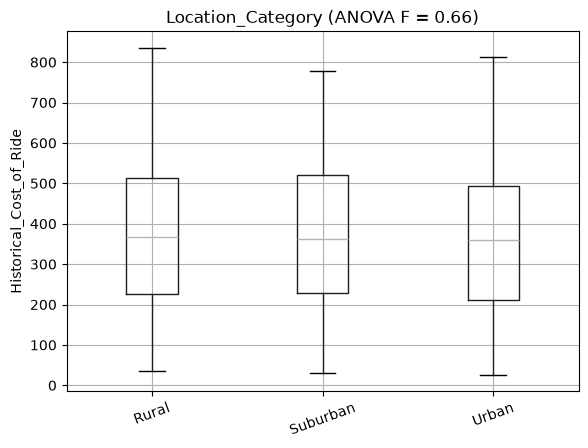

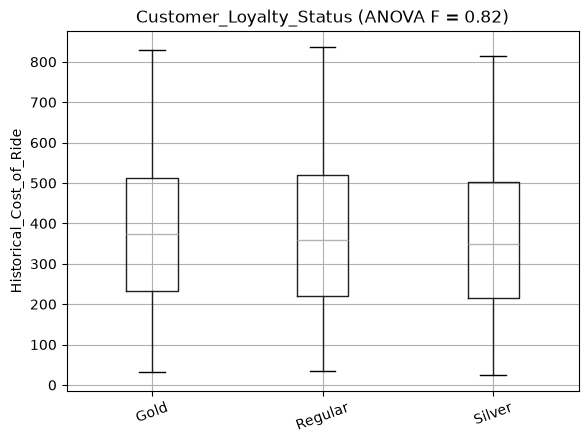

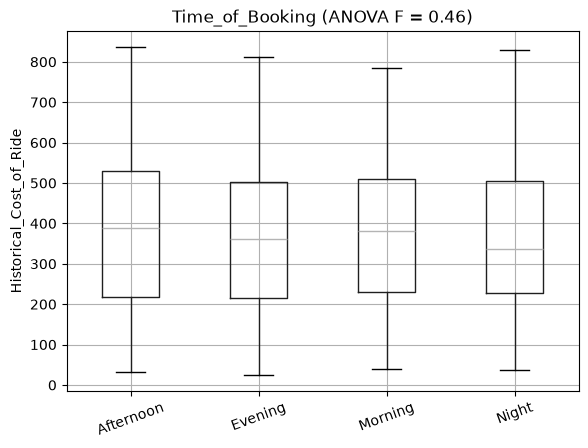

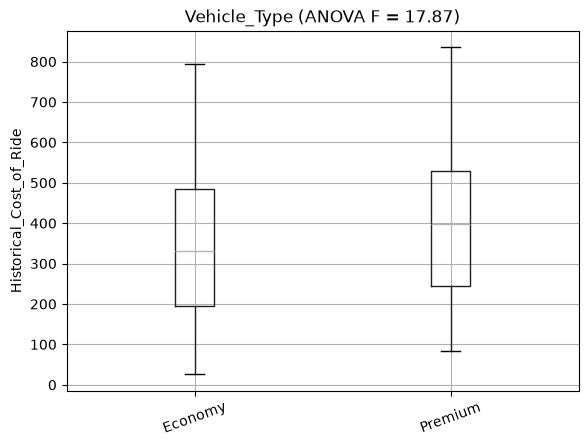

In [ ]:
def plot_categorical_box(dataframe, column, save=False):
    groups = [group[TARGET].values for _, group in dataframe.groupby(column)]
    grand_mean = dataframe[TARGET].mean()
    k = len(groups)
    n = len(dataframe)
    ss_between = sum(len(group) * (group.mean() - grand_mean) ** 2 for group in groups)
    ss_within = sum(((group - group.mean()) ** 2).sum() for group in groups)
    f_stat = (ss_between / (k - 1)) / (ss_within / (n - k))

    ax = dataframe.boxplot(column=TARGET, by=column)
    fig = ax.get_figure()
    fig.set_size_inches(7, 4)

    plt.title(f"{column} (ANOVA F = {f_stat:.2f})")
    plt.suptitle("")
    plt.xlabel("")
    plt.ylabel(TARGET)
    plt.xticks(rotation=20)
    plt.tight_layout()

    if save:
        save_chart.save_chart(fig, f"{column.lower()}_price_boxplot.png")
    else:
        plt.show()

For location, loyalty and time of booking the boxes sit at almost the same height and the F values stay below 1, so none of them really move the price on their own. Vehicle type is the exception with an F of 17.9, where the Premium box sits clearly above Economy, so premium rides generally cost more.

## 6. Price vs demand-supply pressure

The function `plot_demand_supply_scatter` works the same way as `plot_numeric_scatter`, except it is hardcoded to always look at one specific column, `Demand_Supply_Ratio`, rather than taking any column as input.

First, we take in the data table and whether or not we are saving it.

As the goal with this function is again to make a graph which represents `r` while using a simple linear regression, we create an empty graph using `plt.figure`, and then plot in the points one by one, using `plt.scatter` with `alpha=0.4` to make the dots see-through so overlapping dots can be seen/spotted.

Next, to generate the line itself, we calculate the `slope` and the `intercept` using `np.polyfit` so we know where to place the line on the y-axis, and with what steepness, which we then draw using `plt.plot` in red, stretching from the smallest to the largest `Demand_Supply_Ratio` value.

Lastly, we calculate the correlation coefficient `r` using `dataframe["Demand_Supply_Ratio"].corr(dataframe[TARGET])`, again between -1 and 1, where the closer the number is to either -1 or 1, the greater the correlation. In the end, we set the labels and title for the current graph, including `r` rounded to 2 decimals.

After running the function, we can see that `Demand_Supply_Ratio` has a low correlation coefficient of `r=-0.09`, suggesting a weak relationship between `Demand_Supply_Ratio` and `Historical_Cost_of_Ride`, meaning the ratio has little to no effect on cost.

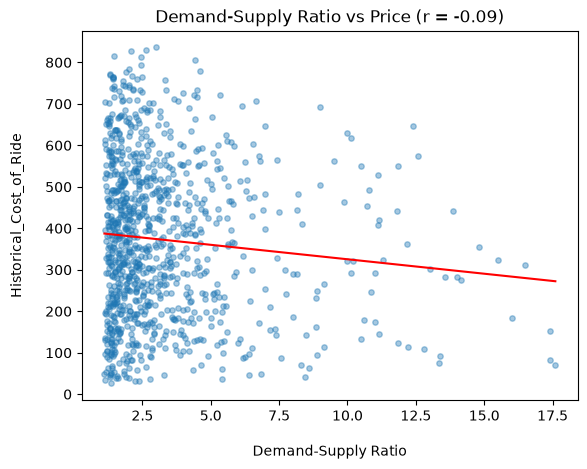

In [ ]:
def plot_demand_supply_scatter(dataframe, save=False):
    fig = plt.figure(figsize=(7, 4))

    plt.scatter(dataframe["Demand_Supply_Ratio"], dataframe[TARGET], alpha=0.4, s=15)

    slope, intercept = np.polyfit(dataframe["Demand_Supply_Ratio"], dataframe[TARGET], 1)
    x_line = np.array(
        [dataframe["Demand_Supply_Ratio"].min(), dataframe["Demand_Supply_Ratio"].max()]
    )
    plt.plot(x_line, slope * x_line + intercept, color="red")

    r = dataframe["Demand_Supply_Ratio"].corr(dataframe[TARGET])
    plt.xlabel("Demand-Supply Ratio", labelpad=15)
    plt.ylabel(TARGET, labelpad=15)
    plt.title(f"Demand-Supply Ratio vs Price (r = {r:.2f})")
    plt.tight_layout()

    if save:
        save_chart.save_chart(fig, "demand_supply_ratio_vs_price.png")
    else:
        plt.show()

The red line is nearly flat and even tilts slightly down, at a correlation of -0.09. So in this historical data higher demand pressure was not matched by higher prices, which is exactly the gap a proper dynamic-pricing model could fill.

## 7. Price by demand-supply level

The function `plot_demand_supply_level` takes in the data table and converts `Demand_Supply_Ratio` from a continuous variable into three equal-sized groups — Low, Medium, and High.

First, this grouping is created using `pd.qcut`, which divides the data into three buckets containing approximately the same number of rows each, and stores the result in a new column named `Demand_Supply_Level`. 

As the objective of this function is to compare price across these three groups rather than plot individual data points, a box plot is generated using `dataframe.boxplot`, grouped by the new `Demand_Supply_Level` column, resulting in one box per group.

Finally, the title is set, the default auto-generated subtitle is removed, both axes are labeled, and spacing is adjusted before the chart is displayed.

After running the function, we observe that price does not differ substantially as the demand-supply level moves from Low to High, indicating that demand relative to supply is not associated with changes in price.

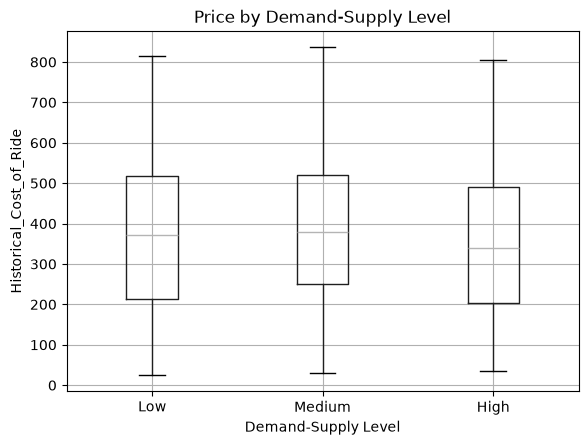

In [8]:
def plot_demand_supply_level(dataframe):
    # split the ratio into three equal-sized groups
    dataframe["Demand_Supply_Level"] = pd.qcut(
        dataframe["Demand_Supply_Ratio"], 3, labels=["Low", "Medium", "High"]
    )

    ax = dataframe.boxplot(column=TARGET, by="Demand_Supply_Level")
    fig = ax.get_figure()
    fig.set_size_inches(7, 4)

    plt.title("Price by Demand-Supply Level")
    plt.suptitle("")
    plt.xlabel("Demand-Supply Level")
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()


plot_demand_supply_level(df)

The three boxes sit at almost the same height, so grouping the ratio still shows no step in price. It agrees with the scatter plot that demand pressure and historical price move independently.

## 8. Key findings and conclusion

- Price was compared against all `NUMERIC_COLUMNS` and `CATEGORICAL_COLUMNS`.
- Only `Expected_Ride_Duration` with a coefficient of `r = 0.93` and `Vehicle_Type` with an F-statistics of `F = 17.87` showed a meaningful relationship with price.
- All other numeric factors showed near-zero correlation with `r` often rangin between [0,0.04].
- All other categorical factors showed low F-statistics with `F` between 0.46 and 0.82, indicating no meaningful effect on price.
- `Demand_Supply_Ratio` showed a very weak correlation with price, with a coefficient of `r = -0.09`, and grouping it into Low/Medium/High levels showed no meaningful difference either
- Price appears driven by fixed ride characteristics, not by supply-and-demand conditions.
- This indicates that dynamic pricing is not present in this dataset.